# Import Necessary Modules

In [1]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.5 MB/s eta 0:00:00


In [2]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import PyPDF2
import warnings
warnings.filterwarnings("ignore")

#  NLTK Setup

In [3]:
for pkg in ['stopwords', 'punkt']:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if pkg == 'punkt' else f'corpora/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

STOPWORDS = set(stopwords.words('english'))
STEMMER   = PorterStemmer()

# Paths

## [DATASET LINK](https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset)

In [4]:
DATA_PATH       = "resume_data.csv"
PROCESSED_PATH  = "processed_resumes.csv"
MODEL_DIR       = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
SVM_PKL         = os.path.join(MODEL_DIR, "svm_pipeline.pkl")
NB_PKL          = os.path.join(MODEL_DIR, "nb_pipeline.pkl")
CNN_PKL         = os.path.join(MODEL_DIR, "textcnn_model.pth")
VOCAB_PKL       = os.path.join(MODEL_DIR, "vocab.pkl")
LABEL_ENC_PKL   = os.path.join(MODEL_DIR, "label_encoder.pkl")

# SECTION 1 — TEXT CLEANING & PREPROCESSING

In [5]:
def clean_text(text: str) -> str:
    """Lowercase, remove special characters, remove stopwords, apply stemming."""
    if not isinstance(text, str) or text.strip() == "" or text.lower() == "nan":
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [STEMMER.stem(w) for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)


def build_resume_text(row: pd.Series) -> str:
    """Concatenate all resume-related columns into a single text field."""
    fields = ['career_objective', 'skills', 'degree_names',
              'major_field_of_studies', 'educational_institution_name']
    parts = [str(row[c]) for c in fields if c in row.index]
    return " ".join(parts)


def build_jd_text(row: pd.Series) -> str:
    """Concatenate all job-description-related columns into a single text field."""
    fields = ['job_position_name', 'skills_required',
              'responsibilities.1', 'educationaL_requirements']
    parts = [str(row[c]) for c in fields if c in row.index]
    return " ".join(parts)

# SECTION 2 — DATA LOADING & EDA

In [6]:
def load_and_eda(csv_path: str) -> pd.DataFrame:
    print("\n" + "="*60)
    print("  STEP 1: DATA LOADING & EDA")
    print("="*60)
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]
    print(f"\n[INFO] Dataset shape : {df.shape}")
    print(f"[INFO] Columns       : {list(df.columns)}\n")
    print(df.head(3).to_string())
    print("\n[INFO] Missing values per column:")
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string() if missing.any() else "  No missing values")
    if 'matched_score' in df.columns:
        df['ats_score'] = (df['matched_score'] * 100).round(2)
    elif 'ats_score' not in df.columns:
        print("[WARN] 'matched_score' not found. Computing proxy ATS score.")
        df['resume_text_raw'] = df.apply(build_resume_text, axis=1)
        df['jd_text_raw']     = df.apply(build_jd_text, axis=1)
        def proxy_score(row):
            res = set(str(row['resume_text_raw']).lower().split())
            jd  = set(str(row['jd_text_raw']).lower().split())
            if not jd:
                return 0.0
            return round(len(res & jd) / len(jd) * 100, 2)
        df['ats_score'] = df.apply(proxy_score, axis=1)
    pos_col = 'job_position_name'
    if pos_col not in df.columns:
        pos_col = [c for c in df.columns if 'position' in c.lower() or 'job' in c.lower()]
        pos_col = pos_col[0] if pos_col else None
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EDA — Resume ATS Dataset", fontsize=14, fontweight='bold')
    axes[0].hist(df['ats_score'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title("ATS Score Distribution")
    axes[0].set_xlabel("ATS Score (0–100)")
    axes[0].set_ylabel("Frequency")
    if pos_col:
        top_pos = df[pos_col].value_counts().head(15)
        axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='coral')
        axes[1].set_title("Top 15 Job Positions")
        axes[1].set_xlabel("Count")
    else:
        axes[1].set_visible(False)
    bins   = [0, 25, 50, 75, 100]
    labels = ['Poor (0–25)', 'Fair (25–50)', 'Good (50–75)', 'Strong (75–100)']
    df['ats_bucket'] = pd.cut(df['ats_score'], bins=bins, labels=labels, include_lowest=True)
    bucket_counts = df['ats_bucket'].value_counts().sort_index()
    colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
    axes[2].bar(bucket_counts.index, bucket_counts.values, color=colors)
    axes[2].set_title("ATS Score Buckets")
    axes[2].set_xlabel("Score Range")
    axes[2].set_ylabel("Count")
    axes[2].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "eda_plots.png"), dpi=120)
    plt.show()
    print("[INFO] EDA plots saved to models/eda_plots.png")
    print("\n[INFO] ATS Score statistics:")
    print(df['ats_score'].describe().round(2).to_string())
    return df

# SECTION 3 — PREPROCESSING (Build resume & JD text, clean, label)


In [7]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    print("\n" + "="*60)
    print("  STEP 2: PREPROCESSING")
    print("="*60)
    df['resume_text'] = df.apply(build_resume_text, axis=1).apply(clean_text)
    df['jd_text']     = df.apply(build_jd_text, axis=1).apply(clean_text)
    df['combined_text'] = df['resume_text'] + " " + df['jd_text']
    df['label'] = (df['ats_score'] >= 50).astype(int)
    before = len(df)
    df = df[df['combined_text'].str.strip().astype(bool)].reset_index(drop=True)
    print(f"[INFO] Rows after removing empty text: {len(df)} (dropped {before - len(df)})")
    print(f"[INFO] Class distribution:\n{df['label'].value_counts().to_string()}")
    df.to_csv(PROCESSED_PATH, index=False)
    print(f"[INFO] Processed data saved to {PROCESSED_PATH}")
    return df

# SECTION 4 — ML MODELS: SVM & NAIVE BAYES

In [8]:
def train_ml_models(df: pd.DataFrame):
    print("\n" + "="*60)
    print("  STEP 3: ML TRAINING — SVM & NAIVE BAYES")
    print("="*60)
    X = df['combined_text'].values
    y = df['label'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"[INFO] Train: {len(X_train)}, Test: {len(X_test)}")
    print("\n[INFO] Training LinearSVC ...")
    svm_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                  sublinear_tf=True, min_df=2)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
    ])
    svm_pipe.fit(X_train, y_train)
    y_pred_svm = svm_pipe.predict(X_test)
    print(f"\n--- SVM Results ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
    print(classification_report(y_test, y_pred_svm,
                                 target_names=['Not Matched', 'Matched']))
    with open(SVM_PKL, 'wb') as f:
        pickle.dump(svm_pipe, f)
    print(f"[INFO] SVM model saved → {SVM_PKL}")
    print("\n[INFO] Training MultinomialNB ...")
    nb_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                  sublinear_tf=True, min_df=2)),
        ('clf',   MultinomialNB(alpha=0.5))
    ])
    nb_pipe.fit(X_train, y_train)
    y_pred_nb = nb_pipe.predict(X_test)
    print(f"\n--- Naive Bayes Results ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
    print(classification_report(y_test, y_pred_nb,
                                 target_names=['Not Matched', 'Matched']))
    with open(NB_PKL, 'wb') as f:
        pickle.dump(nb_pipe, f)
    print(f"[INFO] Naive Bayes model saved → {NB_PKL}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, preds, title in zip(axes,
                                 [y_pred_svm, y_pred_nb],
                                 ["SVM Confusion Matrix", "NB Confusion Matrix"]):
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    xticklabels=['Not Matched', 'Matched'],
                    yticklabels=['Not Matched', 'Matched'])
        ax.set_title(title)
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "ml_confusion_matrices.png"), dpi=120)
    plt.show()
    return svm_pipe, nb_pipe, X_train, X_test, y_train, y_test

# SECTION 5 — DEEP LEARNING: TextCNN (lightweight)


#  Vocabulary builder

In [9]:
def build_vocab(texts, max_vocab=12000):
    freq = {}
    for t in texts:
        for w in str(t).split():
            freq[w] = freq.get(w, 0) + 1
    sorted_words = sorted(freq, key=freq.get, reverse=True)[:max_vocab]
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, w in enumerate(sorted_words, start=2):
        vocab[w] = i
    return vocab


def encode_text(text, vocab, max_len=200):
    tokens = str(text).split()[:max_len]
    ids = [vocab.get(w, 1) for w in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

# Dataset

In [10]:
class ResumeDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.data   = [encode_text(t, vocab, max_len) for t in texts]
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.data[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float32))

# TextCNN Model

In [11]:
class TextCNN(nn.Module):
    """
    Lightweight TextCNN for binary classification.
    Uses three parallel convolution filters (kernel sizes 2, 3, 4),
    max-over-time pooling, dropout, and a fully connected output layer.
    """
    def __init__(self, vocab_size, embed_dim=64, num_filters=64,
                 kernel_sizes=(2, 3, 4), dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(emb))
            c = c.max(dim=2).values
            pooled.append(c)
        out = torch.cat(pooled, dim=1)
        out = self.dropout(out)
        return self.fc(out).squeeze(1)

#  Training loop

In [12]:
def train_dl_model(df: pd.DataFrame):
    print("\n" + "="*60)
    print("  STEP 4: DL TRAINING — TextCNN")
    print("="*60)
    X = df['combined_text'].values
    y = df['label'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    vocab = build_vocab(X_train, max_vocab=12000)
    with open(VOCAB_PKL, 'wb') as f:
        pickle.dump(vocab, f)
    print(f"[INFO] Vocab size: {len(vocab)}, saved → {VOCAB_PKL}")
    MAX_LEN    = 200
    BATCH_SIZE = 64
    EPOCHS     = 5
    LR         = 1e-3
    train_ds = ResumeDataset(X_train, y_train, vocab, MAX_LEN)
    test_ds  = ResumeDataset(X_test,  y_test,  vocab, MAX_LEN)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")
    model     = TextCNN(vocab_size=len(vocab)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    train_losses, val_accs = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dl)
        train_losses.append(avg_loss)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(device), yb.to(device)
                preds = (torch.sigmoid(model(xb)) >= 0.5).float()
                correct += (preds == yb).sum().item()
                total   += yb.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)
        print(f"  Epoch {epoch}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Val Acc: {val_acc:.4f}")
    torch.save(model.state_dict(), CNN_PKL)
    print(f"[INFO] TextCNN model saved → {CNN_PKL}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', color='steelblue')
    axes[0].set_title("TextCNN Training Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
    axes[1].plot(range(1, EPOCHS+1), val_accs, marker='o', color='green')
    axes[1].set_title("TextCNN Validation Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "dl_training_curves.png"), dpi=120)
    plt.show()
    return model, vocab, device

# SECTION 6 — ATS SCORE COMPUTATION


In [13]:
def compute_ats_score_ml(resume_text: str, jd_text: str,
                          model_pkl: str = SVM_PKL) -> dict:
    """
    Compute ATS score using a trained ML pipeline (SVM or NB).
    Score is derived from decision function / probability + keyword overlap.
    """
    with open(model_pkl, 'rb') as f:
        pipe = pickle.load(f)
    res_clean  = clean_text(resume_text)
    jd_clean   = clean_text(jd_text)
    combined   = res_clean + " " + jd_clean
    pred = pipe.predict([combined])[0]
    res_tokens = set(res_clean.split())
    jd_tokens  = set(jd_clean.split())
    overlap     = res_tokens & jd_tokens
    missing     = jd_tokens - res_tokens
    keyword_score = (len(overlap) / len(jd_tokens) * 100) if jd_tokens else 0.0
    try:
        if hasattr(pipe.named_steps['clf'], 'decision_function'):
            raw = pipe.decision_function([combined])[0]
            model_score = round(1 / (1 + np.exp(-raw)) * 100, 2)
        else:
            model_score = round(pipe.predict_proba([combined])[0][1] * 100, 2)
    except Exception:
        model_score = keyword_score
    ats = round(0.6 * model_score + 0.4 * keyword_score, 2)
    return {
        "ats_score"      : ats,
        "model_score"    : model_score,
        "keyword_score"  : round(keyword_score, 2),
        "matched_label"  : "MATCHED" if pred == 1 else "NOT MATCHED",
        "matched_keywords": sorted(overlap)[:20],
        "missing_keywords": sorted(missing)[:20],
    }


def compute_ats_score_dl(resume_text: str, jd_text: str,
                          vocab: dict, model: nn.Module,
                          device: torch.device, max_len: int = 200) -> dict:
    """
    Compute ATS score using the trained TextCNN model.
    """
    res_clean = clean_text(resume_text)
    jd_clean  = clean_text(jd_text)
    combined  = res_clean + " " + jd_clean
    seq = torch.tensor([encode_text(combined, vocab, max_len)],
                       dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        logit = model(seq).item()
    model_score = round(torch.sigmoid(torch.tensor(logit)).item() * 100, 2)
    res_tokens    = set(res_clean.split())
    jd_tokens     = set(jd_clean.split())
    overlap       = res_tokens & jd_tokens
    missing       = jd_tokens - res_tokens
    keyword_score = (len(overlap) / len(jd_tokens) * 100) if jd_tokens else 0.0
    ats = round(0.6 * model_score + 0.4 * keyword_score, 2)
    return {
        "ats_score"       : ats,
        "model_score"     : model_score,
        "keyword_score"   : round(keyword_score, 2),
        "matched_label"   : "MATCHED" if model_score >= 50 else "NOT MATCHED",
        "matched_keywords": sorted(overlap)[:20],
        "missing_keywords": sorted(missing)[:20],
    }


def print_ats_report(result: dict, model_name: str = "Model"):
    print("\n" + "="*50)
    print(f"  ATS REPORT — {model_name}")
    print("="*50)
    print(f"  ATS Score       : {result['ats_score']:.2f} / 100")
    print(f"  Model Score     : {result['model_score']:.2f}")
    print(f"  Keyword Score   : {result['keyword_score']:.2f}")
    print(f"  Decision        : {result['matched_label']}")
    print(f"\n  Matched Keywords ({len(result['matched_keywords'])}):")
    print("    " + ", ".join(result['matched_keywords']) if result['matched_keywords'] else "    None")
    print(f"\n  Missing Keywords ({len(result['missing_keywords'])}):")
    print("    " + ", ".join(result['missing_keywords']) if result['missing_keywords'] else "    None")
    print("="*50)

# SECTION 7 — PDF RESUME READER


In [14]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """Extract plain text from a PDF file using PyPDF2."""
    text = ""
    try:
        with open(pdf_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += (page.extract_text() or "") + " "
    except Exception as e:
        print(f"[ERROR] Could not read PDF: {e}")
    return text.strip()

# SECTION 8 — MAIN ENTRY POINT

In [15]:

def main():
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(
            f"Dataset not found at '{DATA_PATH}'.\n"
            "Download from: https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset\n"
            "and place 'resume_data.csv' in the same directory as this script."
        )

    df = load_and_eda(DATA_PATH)

    df = preprocess(df)

    svm_pipe, nb_pipe, _, _, _, _ = train_ml_models(df)

    dl_model, vocab, device = train_dl_model(df)

    print("\n" + "="*60)
    print("  STEP 5: DEMO ATS SCORING")
    print("="*60)

    sample_resume = """
    John Doe — Data Scientist
    Skills: Python, Machine Learning, Deep Learning, TensorFlow, PyTorch,
            NLP, Scikit-learn, Pandas, NumPy, SQL, Data Visualization,
            Feature Engineering, XGBoost, Model Deployment.
    Education: B.Tech Computer Science, XYZ University, 2020.
    Experience: 2 years at ABC Corp as ML Engineer. Built recommendation
    systems and NLP pipelines. Deployed models using Flask and Docker.
    """

    sample_jd = """
    We are looking for a Data Scientist with expertise in Python, Machine Learning,
    Deep Learning, and NLP. The candidate must have experience with TensorFlow or
    PyTorch, SQL databases, and data visualisation tools. Knowledge of MLOps,
    Docker, and model deployment is a plus. Strong communication skills required.
    Required: 2+ years experience, B.Tech/M.Tech in CS or related field.
    Skills required: Python, ML, Deep Learning, NLP, SQL, TensorFlow, PyTorch.
    """
    svm_result = compute_ats_score_ml(sample_resume, sample_jd, SVM_PKL)
    print_ats_report(svm_result, "SVM")
    nb_result = compute_ats_score_ml(sample_resume, sample_jd, NB_PKL)
    print_ats_report(nb_result, "Naive Bayes")
    dl_result = compute_ats_score_dl(sample_resume, sample_jd, vocab, dl_model, device)
    print_ats_report(dl_result, "TextCNN (DL)")


  STEP 1: DATA LOADING & EDA

[INFO] Dataset shape : (9544, 35)
[INFO] Columns       : ['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']

  address                                                                                                                                                                        

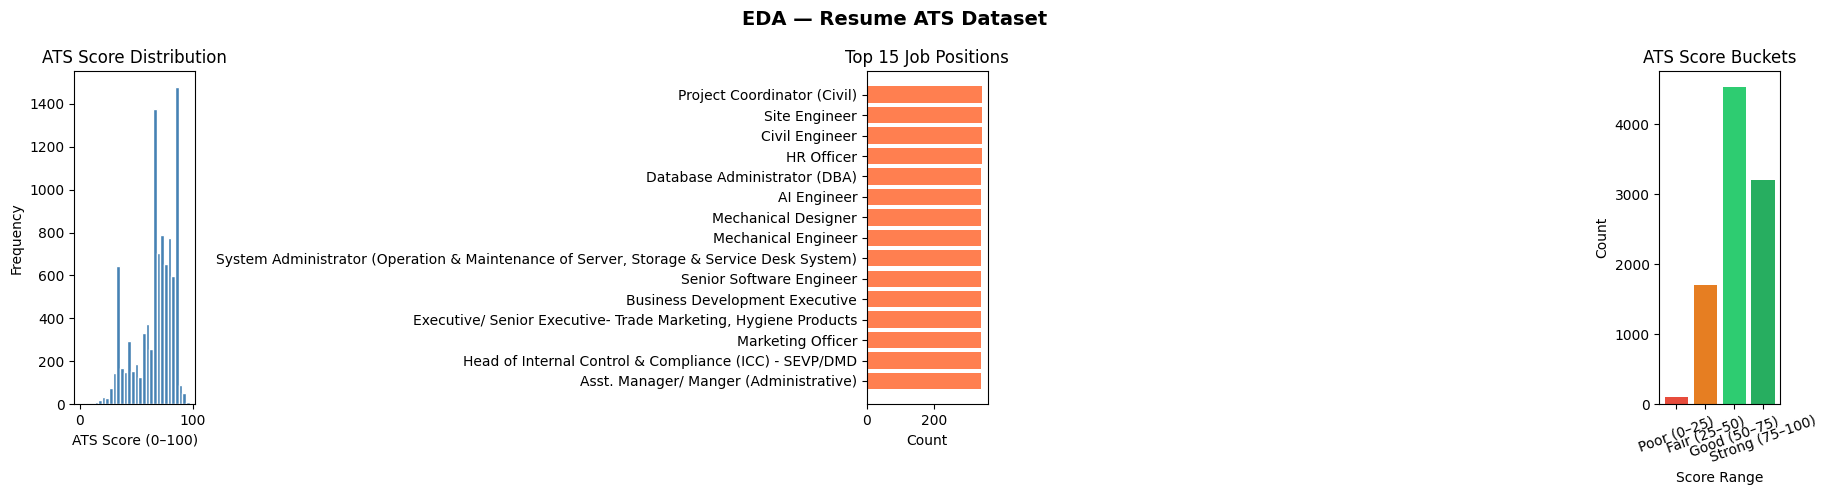

[INFO] EDA plots saved to models/eda_plots.png

[INFO] ATS Score statistics:
count    9544.00
mean       66.08
std        16.70
min         0.00
25%        58.33
50%        68.33
75%        79.33
max        97.00

  STEP 2: PREPROCESSING
[INFO] Rows after removing empty text: 9544 (dropped 0)
[INFO] Class distribution:
label
1    7768
0    1776
[INFO] Processed data saved to processed_resumes.csv

  STEP 3: ML TRAINING — SVM & NAIVE BAYES
[INFO] Train: 7635, Test: 1909

[INFO] Training LinearSVC ...

--- SVM Results ---
Accuracy : 0.8491
              precision    recall  f1-score   support

 Not Matched       0.62      0.50      0.55       355
     Matched       0.89      0.93      0.91      1554

    accuracy                           0.85      1909
   macro avg       0.75      0.71      0.73      1909
weighted avg       0.84      0.85      0.84      1909

[INFO] SVM model saved → models/svm_pipeline.pkl

[INFO] Training MultinomialNB ...

--- Naive Bayes Results ---
Accuracy : 0.805

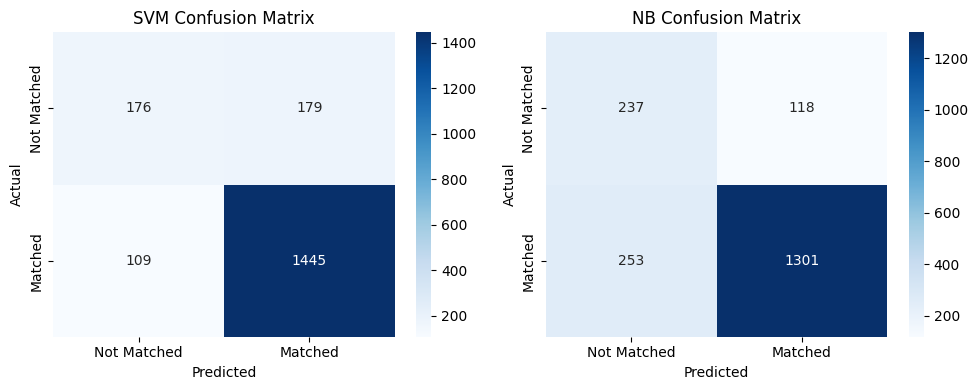


  STEP 4: DL TRAINING — TextCNN
[INFO] Vocab size: 2883, saved → models/vocab.pkl
[INFO] Using device: cpu
  Epoch 1/5  |  Loss: 0.3983  |  Val Acc: 0.8486
  Epoch 2/5  |  Loss: 0.3367  |  Val Acc: 0.8549
  Epoch 3/5  |  Loss: 0.3207  |  Val Acc: 0.8554
  Epoch 4/5  |  Loss: 0.3041  |  Val Acc: 0.8559
  Epoch 5/5  |  Loss: 0.2970  |  Val Acc: 0.8554
[INFO] TextCNN model saved → models/textcnn_model.pth


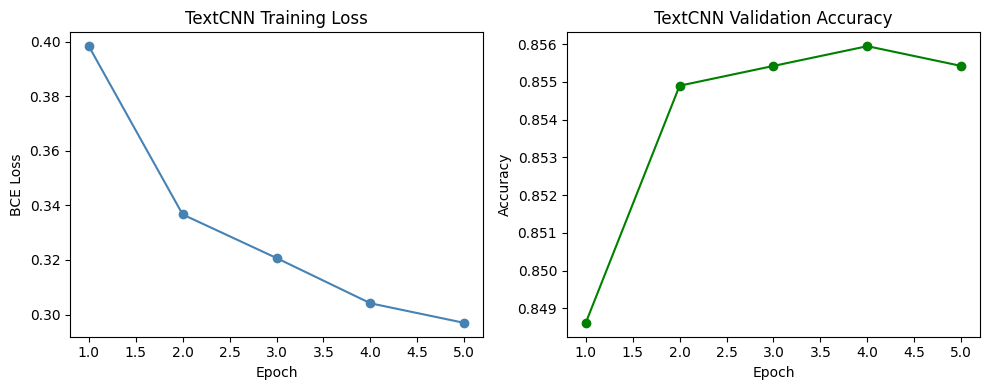


  STEP 5: DEMO ATS SCORING

  ATS REPORT — SVM
  ATS Score       : 60.74 / 100
  Model Score     : 65.81
  Keyword Score   : 53.12
  Decision        : MATCHED

  Matched Keywords (17):
    data, deep, deploy, docker, experi, learn, machin, model, nlp, python, pytorch, scientist, skill, sql, tech, tensorflow, year

  Missing Keywords (15):
    candid, commun, databas, expertis, field, knowledg, look, mlop, must, plu, relat, requir, strong, tool, visualis

  ATS REPORT — Naive Bayes
  ATS Score       : 74.25 / 100
  Model Score     : 88.34
  Keyword Score   : 53.12
  Decision        : MATCHED

  Matched Keywords (17):
    data, deep, deploy, docker, experi, learn, machin, model, nlp, python, pytorch, scientist, skill, sql, tech, tensorflow, year

  Missing Keywords (15):
    candid, commun, databas, expertis, field, knowledg, look, mlop, must, plu, relat, requir, strong, tool, visualis

  ATS REPORT — TextCNN (DL)
  ATS Score       : 73.47 / 100
  Model Score     : 87.04
  Keyword Score

In [16]:
if __name__ == "__main__":
    main()